# SEIRS-SEI Malaria Model - Weekly Free Force-of-Infection (beta) Calibration

**Diagnostic for 2017.** The current calibration assumes the force of infection is
climate-driven: `foi_h = a(T)·b2·(I_M/N)` and `foi_m = a(T)·b1·(I_H/N)`, i.e. a
scalar transmission `b` multiplied by a temperature-dependent biting rate `a(T)`.

To test that assumption, this notebook instead lets the **effective transmission
coefficients `beta_h` (human infection) and `beta_m` (mosquito infection) be free
parameters, one value per week**, estimated with `lmfit` (least_squares). All
other 2017 parameters are fixed at the refined values from `lmfit_results.json`.

The fitted per-week `beta(t)` is then compared against the climate-driven beta
(`a(T)·b1`, `a(T)·b2`) to locate where the climate formulation deviates.

## Step 1 - Imports

`weekly_beta_optimization.py` reuses the shared module
(`lmfit_optimization_shared.py`): same data, same ODE, same weighting. It adds:
- `load_refined_2017()`: the fixed parameters (from `lmfit_results.json`)
- `climate_beta_daily / climate_beta_weekly(...)`: the climate-driven reference beta
- `fit_weekly_betas(...)`: the lmfit least-squares fit of the weekly betas
- `run_weekly_beta_fit(...)`: end-to-end fit + save `weekly_beta_results.json`

In [3]:
import matplotlib.pyplot as plt
from weekly_beta_optimization import *
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


## Step 2 - Fixed 2017 parameters (from the refined lmfit calibration)

`b1` and `b2` are NOT used during the weekly fit; they are only kept to build the
climate-driven reference beta. `H0, k, phi, tau_H, gamma, omega, M_prime` and the
IC fractions are fixed at the refined values.

In [5]:
fixed, state0, fracs, b1, b2 = load_refined_2017()
print('Fixed params (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(2017)}, weekly buckets: {n_weeks_in_year(2017)}')

Fixed params (from lmfit_results.json):
  H0      = 20.2085
  k       = 0.121011
  phi     = 0.49979
  tau_H   = 197.852
  gamma   = 0.00177041
  omega   = 0.0142276
  M_prime = 262206
Climate-driven scalars: b1=0.0417129, b2=0.0706638
IC fractions: {'S_H0_frac': '0.740411', 'E_H0_frac': '0.00106377', 'I_M0_ratio': '0.000500849'}
Initial state: [ 6197     9   944  1219 83522   126    42]
Year days: 365, weekly buckets: 53


## Step 3 - Climate-driven beta (current method reference)

`beta_h_clim(t) = a(T)·b2`, `beta_m_clim(t) = a(T)·b1` with the raw daily
temperature used by the ODE. Shown as daily curves (smooth) and as the
weekly-mean values used to seed the free fit.

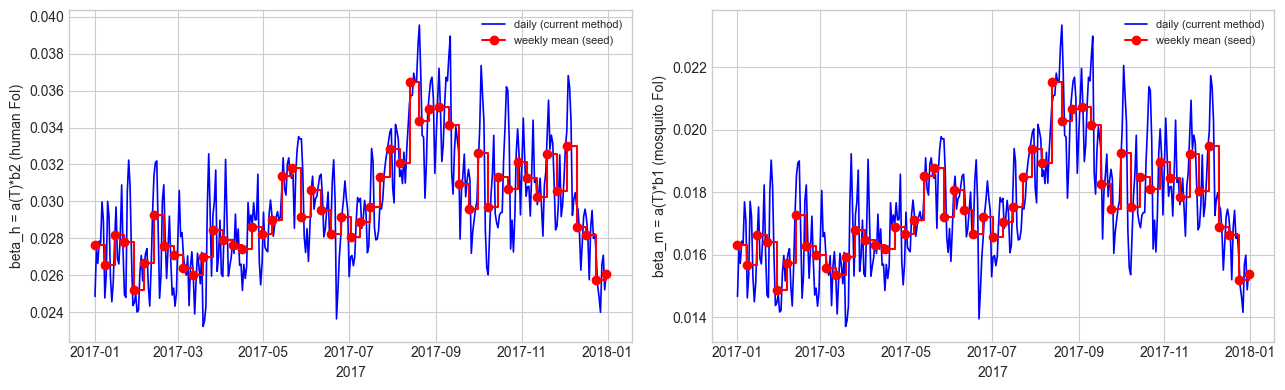

Climate beta_h weekly range: [0.02521, 0.03645]
Climate beta_m weekly range: [0.01488, 0.02151]


In [7]:
nw = n_weeks_in_year(2017)
bh_daily, bm_daily = climate_beta_daily(2017, b1, b2)
bh_week, bm_week = climate_beta_weekly(2017, b1, b2, nw)
dates_2017 = observed_for_year(2017)['date']
week_starts = dates_2017[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_2017, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel('2017')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

## Step 4 - lmfit least-squares fit of the free weekly betas

- **106 free parameters** (`beta_h` and `beta_m` for each of the 53 weekly buckets).
- Seeded from the weekly-mean climate beta above.
- Objective = weighted residuals against the 365 daily observed cases
  (same exponential early-emphasis weighting as the yearly calibration).
- `max_nfev` caps the solver budget (default 1200; `success=False` only means the
  budget was hit before full convergence).

This cell is the long step (~5-15 min).

In [9]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)
print(f'Fitting 2x{nw} free weekly betas with lmfit least_squares (max_nfev={MAX_NFEV})...')
payload = run_weekly_beta_fit(
    year=2017,
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
)

Fitting 2x53 free weekly betas with lmfit least_squares (max_nfev=1200)...
Baseline wMSE (climate-driven beta, refined 2017 params): 55,684.4
Fitting 106 free weekly betas (beta_h, beta_m) seeded from climate...
Fit done: wMSE = 12,188.6 (nfev=1200, success=False)
Saved results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\lmfit_optimization\weekly_beta_results.json


## Step 5 - Results summary

`baseline_wmse` is the weighted MSE with the climate-driven beta (refined 2017
params) - it reproduces `lmfit_results.json`. `weekly_fit_wmse` is the value after
freeing the weekly betas. The gap shows how much of the misfit is due to the
climate formulation of beta.

In [11]:
res = load_weekly_results()
print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
print(f"Weekly-fit wMSE (free beta(t))       : {res['weekly_fit_wmse']:,.1f}")
print(f"wMSE reduction: {(1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100:,.1f}%")
print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2017  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 55,684.4
Weekly-fit wMSE (free beta(t))       : 12,188.6
wMSE reduction: 78.1%
lmfit: nfev=1200, success=False, chisqr=1.714e+07


## Step 6 - Fitted weekly beta vs climate-driven beta

Where the fitted free `beta(t)` departs from `a(T)·b1` / `a(T)·b2` indicates
where the climate formulation is missing or misspecified (e.g. a lag between
rainfall and breeding, or a non-temperature mechanism).

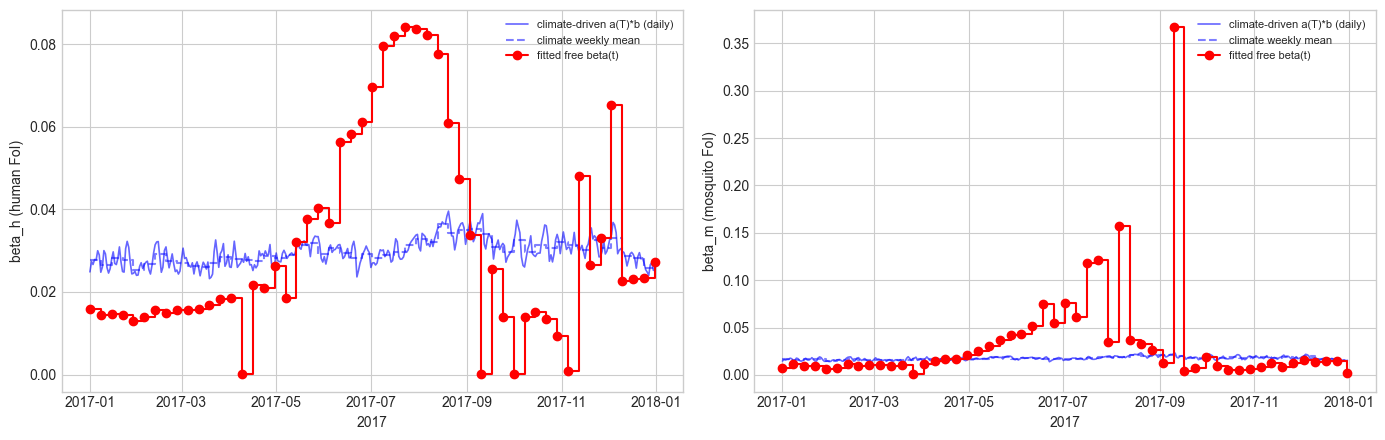

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2017-01-01          0.0276         0.0158          0.0163         0.0071
    1 2017-01-08          0.0266         0.0144          0.0157         0.0112
    2 2017-01-15          0.0282         0.0147          0.0166         0.0094
    3 2017-01-22          0.0278         0.0144          0.0164         0.0093
    4 2017-01-29          0.0252         0.0130          0.0149         0.0067
    5 2017-02-05          0.0267         0.0140          0.0157         0.0070
    6 2017-02-12          0.0293         0.0156          0.0173         0.0111
    7 2017-02-19          0.0276         0.0148          0.0163         0.0090
    8 2017-02-26          0.0271         0.0155          0.0160         0.0101
    9 2017-03-05          0.0264         0.0157          0.0156         0.0109
   10 2017-03-12          0.0260         0.0159          0.0154         0.0091
   11 2017-03-19          0.0270         0.0167     

In [13]:
res = load_weekly_results()
bh_fit = np.array(res['beta_h_weekly_fitted'])
bm_fit = np.array(res['beta_m_weekly_fitted'])
bh_cli = np.array(res['beta_h_weekly_climate'])
bm_cli = np.array(res['beta_m_weekly_climate'])
nw = len(bh_fit)
dates_2017 = observed_for_year(2017)['date']
week_starts = dates_2017[::7][:nw]

bh_daily, bm_daily = climate_beta_daily(
    2017, res['climate_params']['b1'], res['climate_params']['b2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, name, fit, cli_week, cli_daily in [
    (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
    (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
]:
    ax.plot(dates_2017, cli_daily, 'b-', lw=1.2, alpha=0.6, label='climate-driven a(T)*b (daily)')
    ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, label='climate weekly mean')
    ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
    ax.set_ylabel(name)
    ax.set_xlabel('2017')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

tbl = pd.DataFrame({
    'week': np.arange(nw),
    'date': week_starts.values,
    'beta_h_climate': bh_cli,
    'beta_h_fitted': bh_fit,
    'beta_m_climate': bm_cli,
    'beta_m_fitted': bm_fit,
})
print(tbl.round(4).to_string(index=False))

## Step 7 - Model vs observed cases with the free weekly beta

Overlaying the model trajectory (with free weekly beta) on the observed cases.

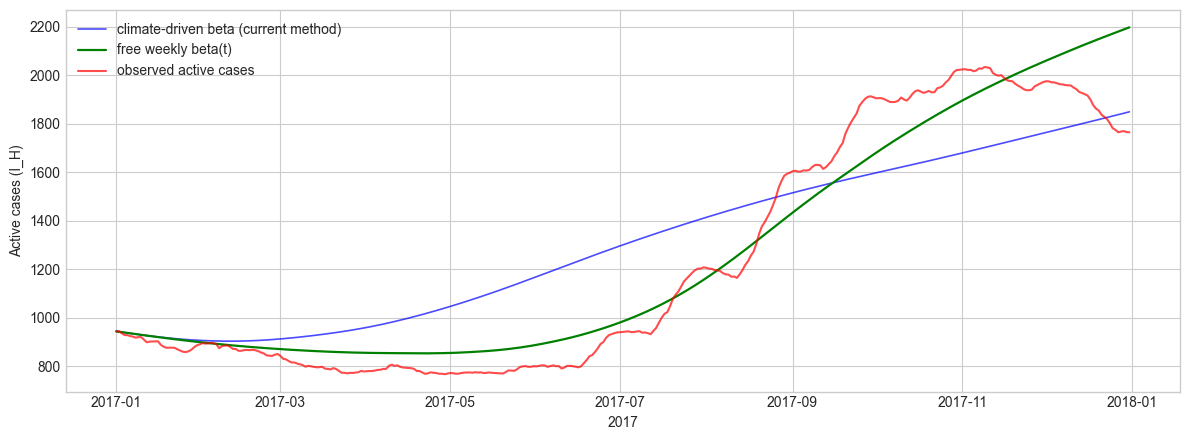

In [15]:
res = load_weekly_results()
fixed, state0, fracs, b1, b2 = load_refined_2017()
bh_fit = np.array(res['beta_h_weekly_fitted'])
bm_fit = np.array(res['beta_m_weekly_fitted'])
dates, IH, _ = simulate_year(2017, state0, fixed, bh_fit, bm_fit)
obs = observed_for_year(2017)

full = dict(fixed)
full['b1'], full['b2'] = b1, b2
dates0, IH0, _ = simulate_year(2017, state0, full)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, label='climate-driven beta (current method)')
ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, label='free weekly beta(t)')
ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, label='observed active cases')
ax.set_ylabel('Active cases (I_H)')
ax.set_xlabel('2017')
ax.legend()
plt.tight_layout()
plt.show()

## Notes

- `success=False` just means the least_squares evaluation budget was reached; the
  reported betas are the best found within that budget.
- The free weekly beta can absorb any mechanism the fixed climate formulation
  misses (lagged rain effects, behaviour, reporting artefacts), so a large wMSE
  improvement only localises *where* the formulation fails - it is not a
  predictive model.
- Results are saved to `weekly_beta_results.json`.
- To change the weighting or the fit budget, edit `WEIGHT_KW` / `MAX_NFEV` in
  Step 4 and re-run from there.